# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Nguyễn Thành Đạt"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600203"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://cat-sic-enabling-existing.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 2.9% | Mem: 0.7/16.0GB | Power: 34W | Temp: 32°C
   GPU 1 [T4] 🟢 Util: 9.1% | Mem: 2.0/16.0GB | Power: 44W | Temp: 38°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 1.8% | Mem: 1.7/80.0GB | Power: 34W | Temp: 42°C
   GPU 1 [A100] 🟢 Util: 7.1% | Mem: 1.3/80.0GB | Power: 31W | Temp: 38°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 5.3% | Mem: 1.7/32.0GB | Power: 41W | Temp: 31°C
   GPU 1 [V100] 🟢 Util: 14.9% | Mem: 1.3/32.0GB | Power: 32W | Temp: 36°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 12.6% | Mem: 1.2/16.0GB | Power: 27W | Temp: 44°C
   GPU 1 [T4] 🟢 Util: 11.3% | Mem: 1.0/16.0GB | Power: 21W | Temp: 44°C


In [25]:
display_student_header()

In [5]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     8.1%
Memory Used:         11.0 GB
Memory Capacity:     288.0 GB
Total Power Draw:    263 W
Node Count:          4


In [26]:
display_student_header()

---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 48.0%


In [27]:
display_student_header()

In [7]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


In [28]:
display_student_header()

---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2225     36.4    % medium
A100       $3.67       $2.2878     37.7    % high
V100       $2.48       $1.8396     25.8    % medium


In [29]:
display_student_header()

In [9]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [30]:
display_student_header()

In [10]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 2

   ⚠️  Preempted:
      - spot-t4-002 (ran for 2s, 120s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0007
   On-demand equiv:  $0.0024
   Total saved:      $0.0017 (70.0%)


In [31]:
display_student_header()

---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [32]:
display_student_header()

In [12]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 48.0% within thresholds [25.0-70.0%]
   Current utilization: 48.0%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 48.0% | Nodes: 4→4
   Cycle 2: no_action    | Util: 48.0% | Nodes: 4→4
   Cycle 3: no_action    | Util: 48.0% | Nodes: 4→4
   Cycle 4: no_action    | Util: 48.0% | Nodes: 4→4
   Cycle 5: no_action    | Util: 48.0% | Nodes: 4→4


In [33]:
display_student_header()

---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [34]:
display_student_header()

In [14]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [35]:
display_student_header()

In [15]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [36]:
display_student_header()

In [16]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 48.0% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.0470 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


In [37]:
display_student_header()

---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

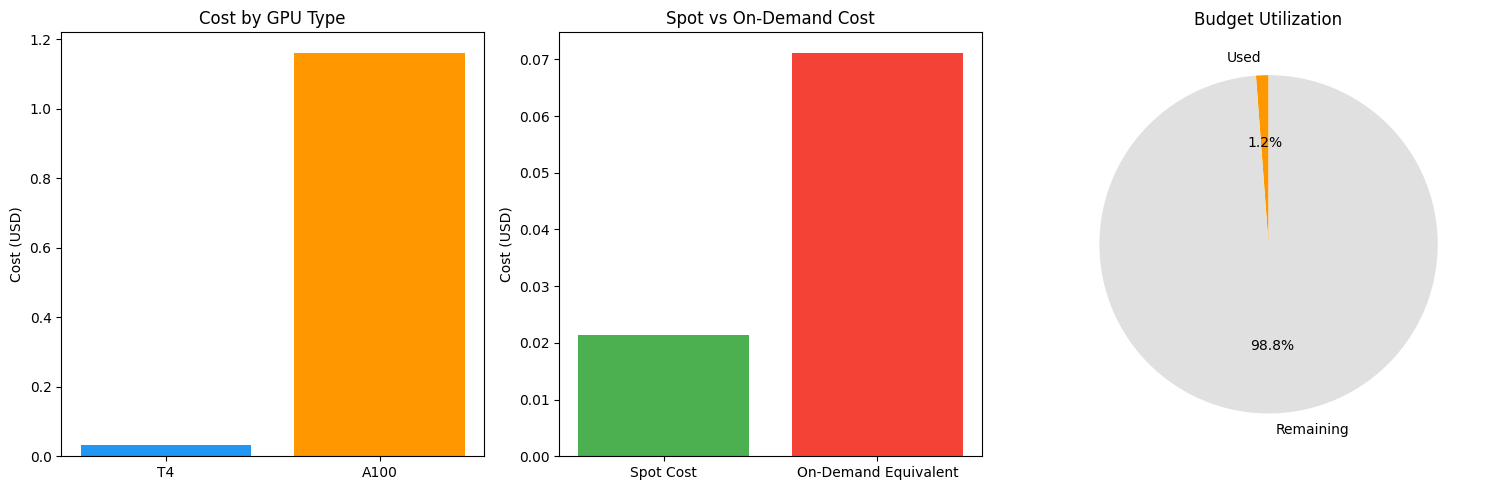

📊 Chart saved as finops_cost_breakdown.png


In [17]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

In [38]:
display_student_header()

📈 Collecting time-series data (10 snapshots)...


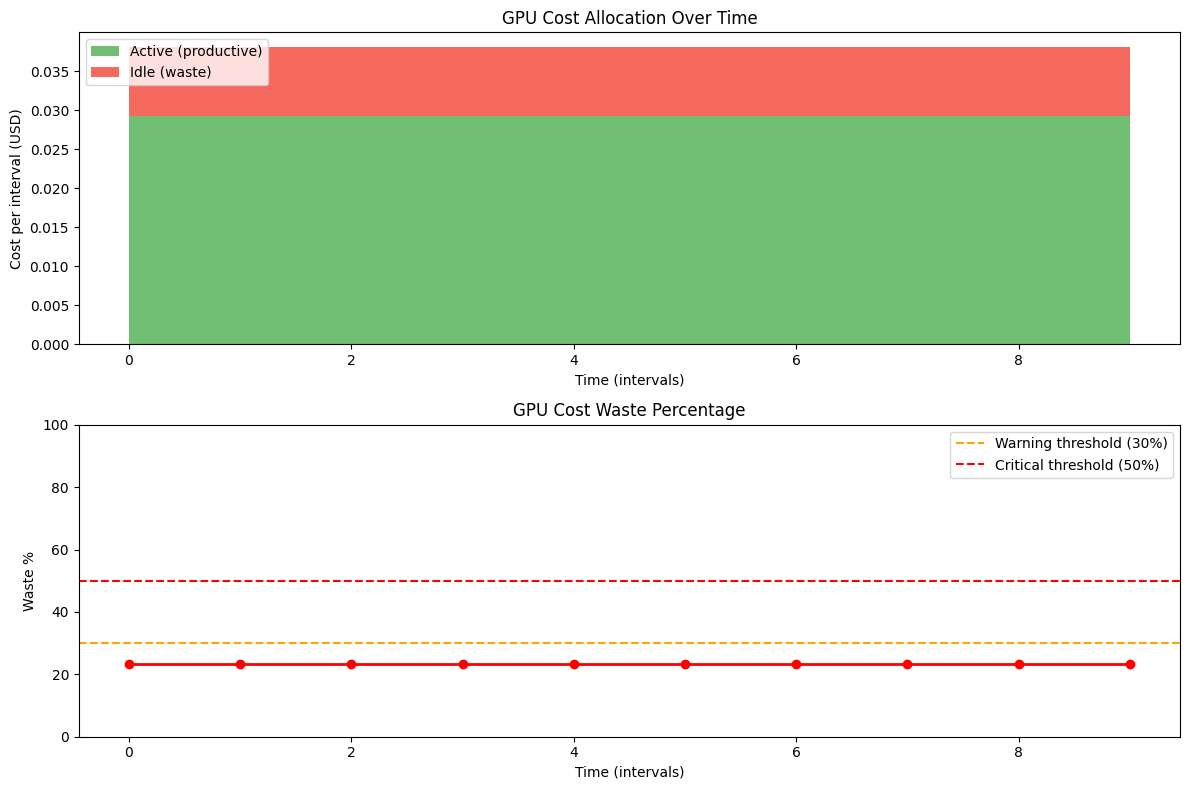

In [18]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
display_student_header()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 48.0% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 68.3% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: no_action - Utilization 68.3% within thresholds [25.0-70.0%]

4️⃣  Cost analysis:
   Total cost/interval: $0.038056
   Waste: 0.0%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0857 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


In [40]:
display_student_header()

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [41]:
display_student_header()

In [21]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.1W
   Temp: 42C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.063
   temp_c: 42.0

   Method: pynvml

Ready for training.


In [42]:
display_student_header()

In [22]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:03<00:00, 47.4MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [23]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 2.2379 | Acc: 20.8% | Time: 41.4s | Samples: 40
   Epoch 2/3 | Loss: 1.5685 | Acc: 41.6% | Time: 42.0s | Samples: 40
   Epoch 3/3 | Loss: 1.2845 | Acc: 53.4% | Time: 46.3s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      129.8s
   Peak memory:     0.82 GB
   Avg GPU util:    93.9%
   Avg power:       66.4W
   Avg temperature: 68.6C
   Max GPU util:    98.0%
   Estimated cost:  $0.012619


In [43]:
display_student_header()

In [24]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_3232/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_3232/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9711 | Acc: 28.6% | Time: 24.0s | Samples: 40
   Epoch 2/3 | Loss: 1.3419 | Acc: 50.8% | Time: 23.7s | Samples: 40
   Epoch 3/3 | Loss: 1.0263 | Acc: 63.3% | Time: 23.2s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      70.9s
   Peak memory:     0.60 GB
   Avg GPU util:    73.7%
   Avg power:       64.1W
   Avg temperature: 76.8C
   Max GPU util:    90.0%
   Estimated cost:  $0.006897


In [44]:
display_student_header()

FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                129.8           70.9            1.83x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012619       $0.006897       $0.005722 saved
Cost Saving %             ---             ---             45.3%
Avg GPU Util %            93.9            73.7           
Avg Power (W)             66.4            64.1           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.59 -> SAVE $3.81
   1 week training: FP32=$58.80 vs AMP=$32.14 -> SAVE $26.66
   1 month training: FP32=$252.00 vs AMP=$137.73 -> SAVE $114.27


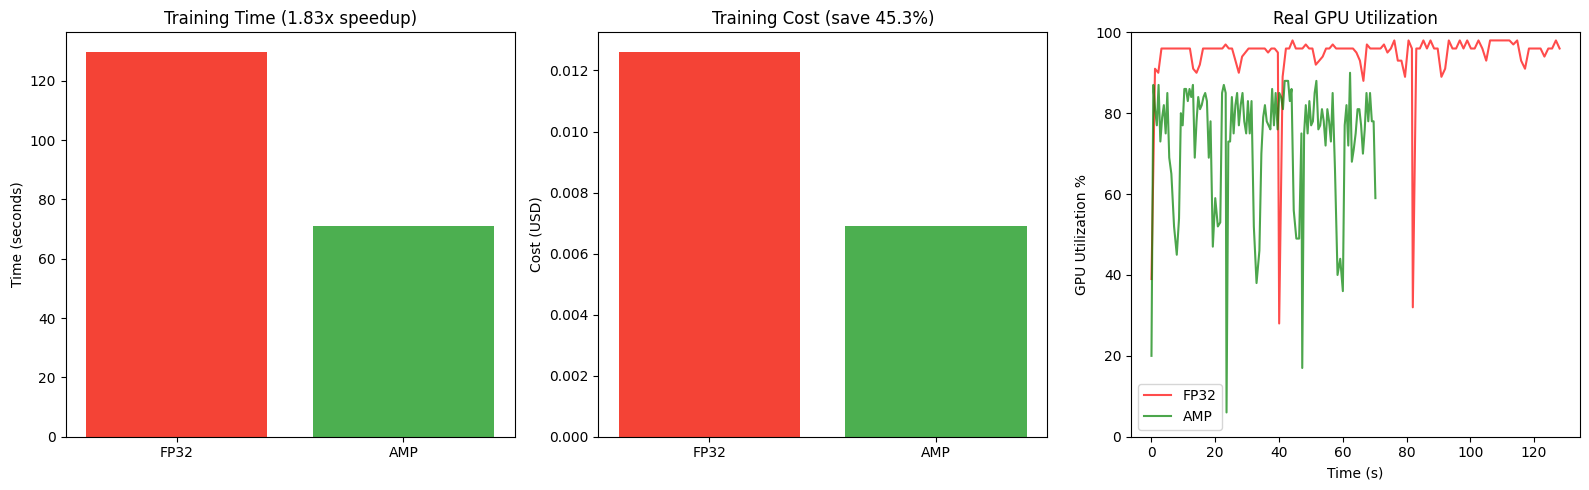

In [45]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
display_student_header()

In [47]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012600 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.002100 | Saved: $0.004800

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.014700
   Total Savings:   $0.004800
   Workloads:       2

   Cost snapshot taken: waste=18.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


In [48]:
display_student_header()

Real GPU Telemetry During Training


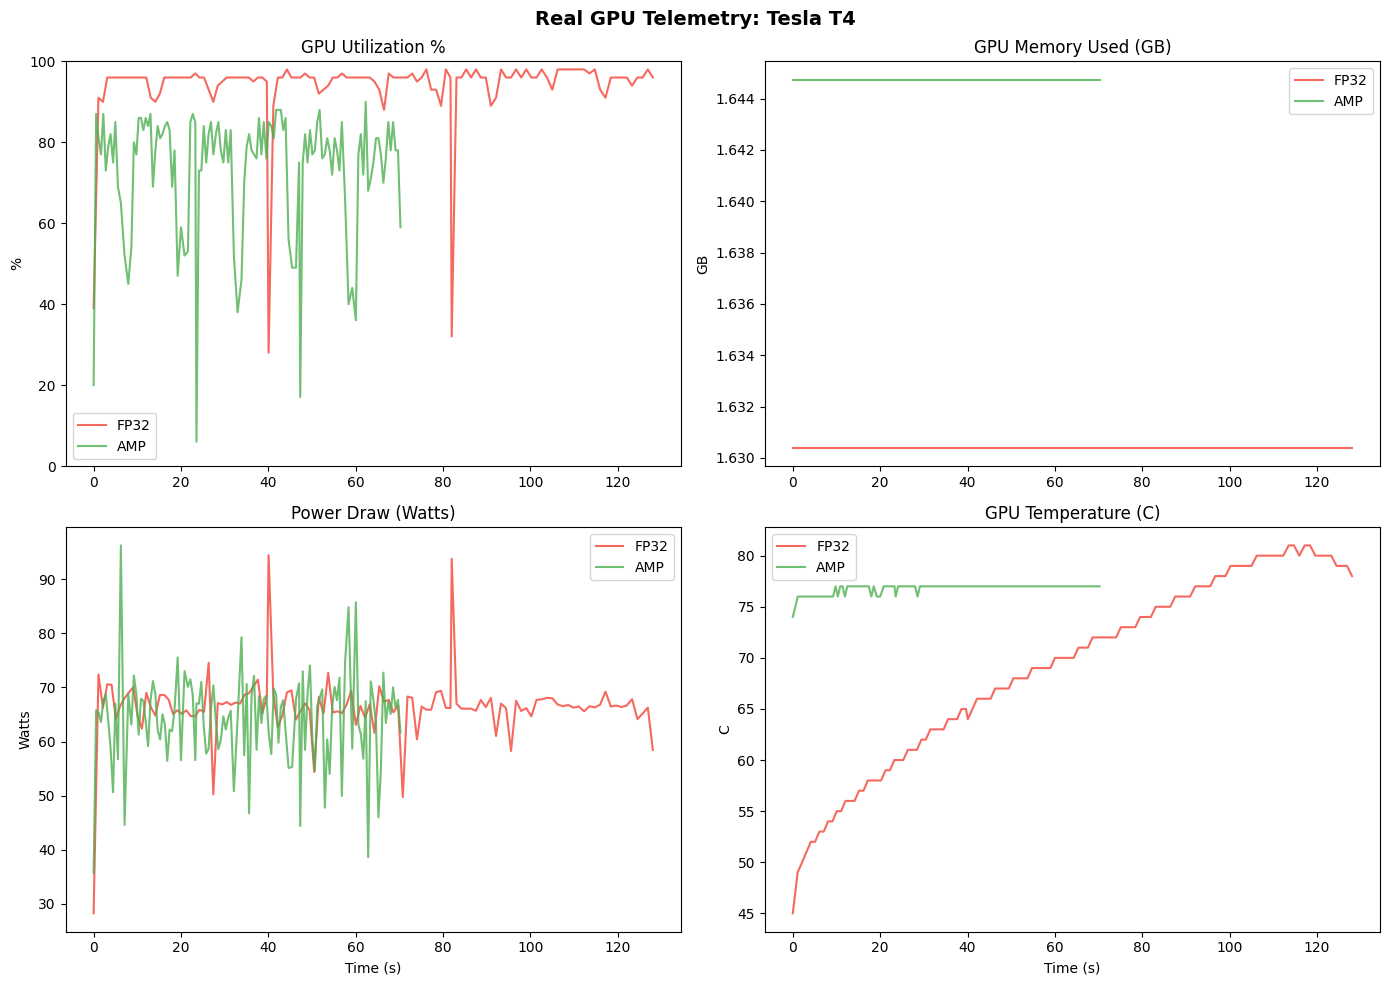

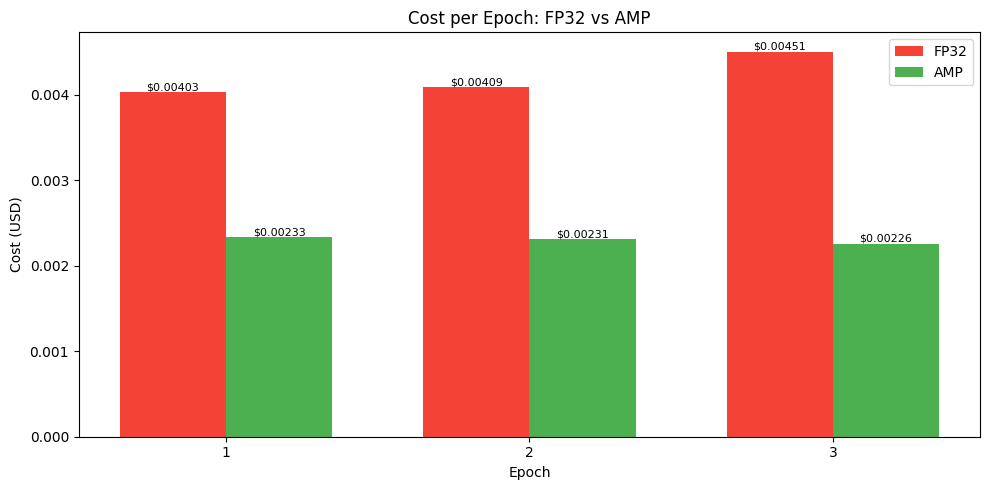


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [49]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [53]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Analyze multi-GPU training costs
    
    Parameters:
        base_time_hours (float): Single-GPU training time in hours
        gpu_type (str): GPU type (T4, A100, etc.)
        gpu_counts (list): List of GPU counts to analyze (e.g., [1, 2, 4, 8])
        scaling_factors (dict, optional): Scaling efficiency factors
                                         If None, assume realistic sub-linear scaling
    
    Returns:
        dict: Analysis with costs, times, and efficiency metrics
    """
    if scaling_factors is None:
        scaling_factors = {
            1: 1.0, 2: 1.8, 4: 3.2, 8: 5.5, 16: 9.0
        }

    price_per_gpu = GPU_PRICING.get(gpu_type, 0.35)

    results = []
    for count in gpu_counts:
        scaling = scaling_factors.get(count, count ** 0.85)
        time_hours = base_time_hours / scaling
        total_cost = time_hours * price_per_gpu * count
        cost_per_unit = (base_time_hours * price_per_gpu) / scaling
        results.append({
            'gpu_count': count,
            'scaling_factor': round(scaling, 2),
            'time_hours': round(time_hours, 3),
            'total_cost': round(total_cost, 4),
            'cost_per_unit': round(cost_per_unit, 4),
            'speedup': round(scaling, 2),
        })

    best = min(results, key=lambda x: x['cost_per_unit'])
    return {
        'results': results,
        'optimal_gpu_count': best['gpu_count'],
        'gpu_type': gpu_type,
        'price_per_gpu': price_per_gpu,
    }


base_training_time = 2.0
test_gpu_counts = [1, 2, 4, 8]

analysis = analyze_multi_gpu_cost(base_training_time, 'T4', test_gpu_counts)

print(f"\n{'GPU':<6} {'Scale':<8} {'Time(h)':<9} {'Cost':<10} {'Cost/Unit':<11} {'Speedup'}")
print("-" * 54)
for r in analysis['results']:
    print(f"{r['gpu_count']:<6} {r['scaling_factor']:<8.1f} {r['time_hours']:<9.3f} "
          f"${r['total_cost']:<9.4f} ${r['cost_per_unit']:<10.4f} {r['speedup']:.2f}x")

print("-" * 54)
print(f"\n  Optimal: {analysis['optimal_gpu_count']} GPU(s) ({analysis['gpu_type']}) "
      f"@ ${analysis['price_per_gpu']}/hr")

EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPU    Scale    Time(h)   Cost       Cost/Unit   Speedup
------------------------------------------------------
1      1.0      2.000     $0.7000    $0.7000     1.00x
2      1.8      1.111     $0.7778    $0.3889     1.80x
4      3.2      0.625     $0.8750    $0.2187     3.20x
8      5.5      0.364     $1.0182    $0.1273     5.50x
------------------------------------------------------

  Optimal: 8 GPU(s) (T4) @ $0.35/hr


In [51]:
display_student_header()

In [58]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase project costs with confidence intervals
    
    Parameters:
        phases (list): List of phase dictionaries with:
                      - name: str
                      - gpu_type: str
                      - gpu_count: int
                      - duration_hours: float
                      - uncertainty_pct: float (e.g., 0.2 for 20% uncertainty)
        contingency_pct (float): Percentage buffer for unexpected costs (default 20%)
        confidence_level (float): Confidence level for intervals (0.95 = 95%)
    
    Returns:
        dict: Forecast with base cost, contingency, confidence intervals
    """
    from math import sqrt

    # Z-score for confidence level
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)

    phase_results = []
    total_base = 0.0
    total_variance = 0.0

    for p in phases:
        price = GPU_PRICING.get(p['gpu_type'], 0.35)
        cost = p['duration_hours'] * price * p['gpu_count']
        uncertainty = cost * p['uncertainty_pct']
        variance = (uncertainty ** 2)

        total_base += cost
        total_variance += variance

        phase_results.append({
            'name': p['name'],
            'gpu_type': p['gpu_type'],
            'gpu_count': p['gpu_count'],
            'duration_hours': p['duration_hours'],
            'base_cost': round(cost, 2),
            'uncertainty_pct': p['uncertainty_pct'],
            'uncertainty_range': round(uncertainty, 2),
            'variance': variance,
        })

    # Aggregate confidence interval (RSS - Root Sum Square)
    aggregate_std = sqrt(total_variance)
    ci_half_width = z * aggregate_std

    # Contingency buffer
    contingency = total_base * (contingency_pct / 100)

    # Final forecast
    total_expected = total_base + contingency
    best_case = total_base - ci_half_width
    worst_case = total_base + ci_half_width + contingency

    # Percentage breakdown
    for r in phase_results:
        r['pct_of_total'] = round(r['base_cost'] / total_base * 100, 1)

    # Risk phases (high uncertainty)
    risk_phases = sorted(phase_results, key=lambda x: x['uncertainty_pct'], reverse=True)[:2]

    return {
        'phases': phase_results,
        'total_base_cost': round(total_base, 2),
        'contingency_pct': contingency_pct,
        'contingency_amount': round(contingency, 2),
        'confidence_level': confidence_level,
        'z_score': z,
        'aggregate_std': round(aggregate_std, 2),
        'ci_half_width': round(ci_half_width, 2),
        'forecast_expected': round(total_expected, 2),
        'forecast_best': round(best_case, 2),
        'forecast_worst': round(worst_case, 2),
        'risk_phases': [p['name'] for p in risk_phases],
    }


# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

# Run forecast
forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)

# Display phase breakdown
print(f"\n  Confidence Level: {forecast['confidence_level']*100:.0f}%  |  Z-score: {forecast['z_score']}")
print(f"  Contingency: {forecast['contingency_pct']}%\n")
print(f"  {'Phase':<24} {'GPU':<6} {'#GPU':<5} {'Hours':<7} {'Cost':<10} {'Uncert%':<9} {'Range':<10} {'%Total'}")
print("  " + "-" * 88)
for p in forecast['phases']:
    print(f"  {p['name']:<24} {p['gpu_type']:<6} {p['gpu_count']:<5} {p['duration_hours']:<7} "
          f"${p['base_cost']:<9.2f} {p['uncertainty_pct']*100:<8.0f}% ${p['uncertainty_range']:<9.2f} {p['pct_of_total']:.0f}%")

print("  " + "-" * 88)
print(f"  {'BASE COST TOTAL':<24} {'':>33} ${forecast['total_base_cost']:.2f}")

# Scenario summary
print(f"\n  {'='*50}")
print(f"  {'SCENARIO ANALYSIS':^50}")
print(f"  {'='*50}")
print(f"  {'Best Case (lower bound):':<30} ${forecast['forecast_best']:.2f}")
print(f"  {'Expected (with contingency):':<30} ${forecast['forecast_expected']:.2f}")
print(f"  {'Worst Case (upper bound):':<30} ${forecast['forecast_worst']:.2f}")
print(f"  {'Uncertainty Range:':<30} +/- ${forecast['ci_half_width']:.2f}")
print(f"  {'='*50}")

print(f"\n  Risk Phases (highest uncertainty):")
for name in forecast['risk_phases']:
    print(f"    - {name}")

EXERCISE 8.5.2: Project Cost Forecasting

  Confidence Level: 95%  |  Z-score: 1.96
  Contingency: 20%

  Phase                    GPU    #GPU  Hours   Cost       Uncert%   Range      %Total
  ----------------------------------------------------------------------------------------
  Data Preparation         T4     1     40      $14.00     15      % $2.10      0%
  Model Training           A100   4     120     $1761.60   25      % $440.40    50%
  Hyperparameter Tuning    A100   8     60      $1761.60   30      % $528.48    50%
  Model Evaluation         T4     2     20      $14.00     10      % $1.40      0%
  ----------------------------------------------------------------------------------------
  BASE COST TOTAL                                            $3551.20

                  SCENARIO ANALYSIS                 
  Best Case (lower bound):       $2202.85
  Expected (with contingency):   $4261.44
  Worst Case (upper bound):      $5609.79
  Uncertainty Range:             +/- $1348.

In [54]:
display_student_header()

In [59]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Analyze and prioritize optimization strategies
    
    Parameters:
        current_config (dict): Current training configuration
        optimization_strategies (list): List of strategy dicts with:
            - name, savings_pct, implementation_effort, risk_level, dependencies
    
    Returns:
        dict: Prioritized recommendations with cumulative savings
    """
    # Effort mapping: numeric score for ratio calculation
    effort_score = {'LOW': 1, 'MEDIUM': 3, 'HIGH': 7}
    risk_score = {'LOW': 1, 'MEDIUM': 3, 'HIGH': 5}

    # Calculate baseline cost
    gpu_price = GPU_PRICING.get(current_config['gpu_type'], 0.35)
    baseline_cost = (current_config['duration_hours']
                     * gpu_price
                     * current_config['gpu_count'])

    # Score each strategy: higher = better
    ranked = []
    for s in optimization_strategies:
        eff = effort_score.get(s['implementation_effort'], 2)
        risk = risk_score.get(s['risk_level'], 2)

        # Priority score: savings * (1/effort) * (1/risk)
        priority = (s['savings_pct'] / eff) * (1 / risk)
        savings_dollar = baseline_cost * s['savings_pct']

        # Check if dependencies are satisfied
        deps_met = all(d in [x['name'] for x in ranked] for d in s.get('dependencies', []))

        ranked.append({
            'name': s['name'],
            'savings_pct': s['savings_pct'],
            'savings_dollar': round(savings_dollar, 2),
            'effort': s['implementation_effort'],
            'risk': s['risk_level'],
            'priority_score': round(priority, 4),
            'dependencies_met': deps_met,
            'dependencies': s.get('dependencies', []),
        })

    # Sort by: (1) dependencies met, (2) priority score
    ranked.sort(key=lambda x: (x['dependencies_met'], x['priority_score']), reverse=True)

    # Cumulative savings
    cumulative = 0.0
    for r in ranked:
        if r['dependencies_met']:
            cumulative += r['savings_dollar']
        r['cumulative_savings'] = round(cumulative, 2)

    total_cumulative = cumulative

    # Quick wins: LOW effort, LOW risk, HIGH savings
    quick_wins = [r for r in ranked
                  if r['effort'] == 'LOW' and r['risk'] == 'LOW']
    # Big bets: HIGH effort but high savings
    big_bets = [r for r in ranked
                if r['effort'] == 'HIGH' and r['savings_pct'] >= 0.30]
    # Risky high savings
    risky = [r for r in ranked
             if r['risk'] == 'HIGH' and r['savings_pct'] >= 0.40]

    return {
        'baseline_cost': round(baseline_cost, 2),
        'strategies': ranked,
        'total_savings_pct': round(sum(r['savings_pct'] for r in ranked), 2),
        'total_savings_dollar': round(total_cumulative, 2),
        'quick_wins': [r['name'] for r in quick_wins],
        'big_bets': [r['name'] for r in big_bets],
        'risky_high_savings': [r['name'] for r in risky],
    }


current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

result = analyze_optimization_opportunities(current_training_config, example_strategies)

# Display
print(f"\n  Baseline Cost: ${result['baseline_cost']:.2f} "
      f"({current_training_config['gpu_count']}x {current_training_config['gpu_type']}, "
      f"{current_training_config['duration_hours']}h)")
print(f"\n  {'#':<3} {'Strategy':<35} {'Savings%':<10} {'Savings$':<12} "
      f"{'Effort':<9} {'Risk':<7} {'Priority':<10} {'Cumul.$':<12} {'Deps'}")
print("  " + "-" * 110)
for i, s in enumerate(result['strategies'], 1):
    deps_str = "Yes" if s['dependencies_met'] else "No"
    print(f"  {i:<3} {s['name']:<35} {s['savings_pct']*100:<9.0f}% "
          f"${s['savings_dollar']:<11.2f} {s['effort']:<9} {s['risk']:<7} "
          f"{s['priority_score']:<10.4f} ${s['cumulative_savings']:<11.2f} {deps_str}")

print("  " + "-" * 110)
print(f"\n  {'='*55}")
print(f"  {'OPTIMIZATION ROADMAP SUMMARY':^55}")
print(f"  {'='*55}")
print(f"  {'Quick Wins (do first):':<30} {len(result['quick_wins'])} strategies")
for name in result['quick_wins']:
    print(f"    + {name}")
print(f"\n  {'Big Bets (high effort, high return):':<30} {len(result['big_bets'])} strategies")
for name in result['big_bets']:
    print(f"    + {name}")
print(f"\n  {'High Risk + High Savings:':<30} {len(result['risky_high_savings'])} strategies")
for name in result['risky_high_savings']:
    print(f"    ! {name}")
print(f"\n  {'='*55}")
print(f"  {'Total cumulative savings:':<30} ${result['total_savings_dollar']:.2f}")
print(f"  {'Combined savings rate:':<30} {result['total_savings_pct']*100:.0f}%")
print(f"  {'='*55}")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

  Baseline Cost: $1468.00 (4x A100, 100h)

  #   Strategy                            Savings%   Savings$     Effort    Risk    Priority   Cumul.$      Deps
  --------------------------------------------------------------------------------------------------------------
  1   Switch to Mixed Precision (AMP)     25       % $367.00      LOW       LOW     0.2500     $367.00      Yes
  2   Optimize Batch Size                 15       % $220.20      LOW       LOW     0.1500     $587.20      Yes
  3   Implement Early Stopping            20       % $293.60      MEDIUM    LOW     0.0667     $880.80      Yes
  4   Use Spot Instances                  60       % $880.80      MEDIUM    HIGH    0.0400     $1761.60     Yes
  5   Switch to More Efficient GPU Type   40       % $587.20      HIGH      MEDIUM  0.0190     $2348.80     Yes
  -------------------------------------------------------------------------------------------------------------

In [55]:
display_student_header()

EXERCISE 8.5.4: Integrated Cost Dashboard


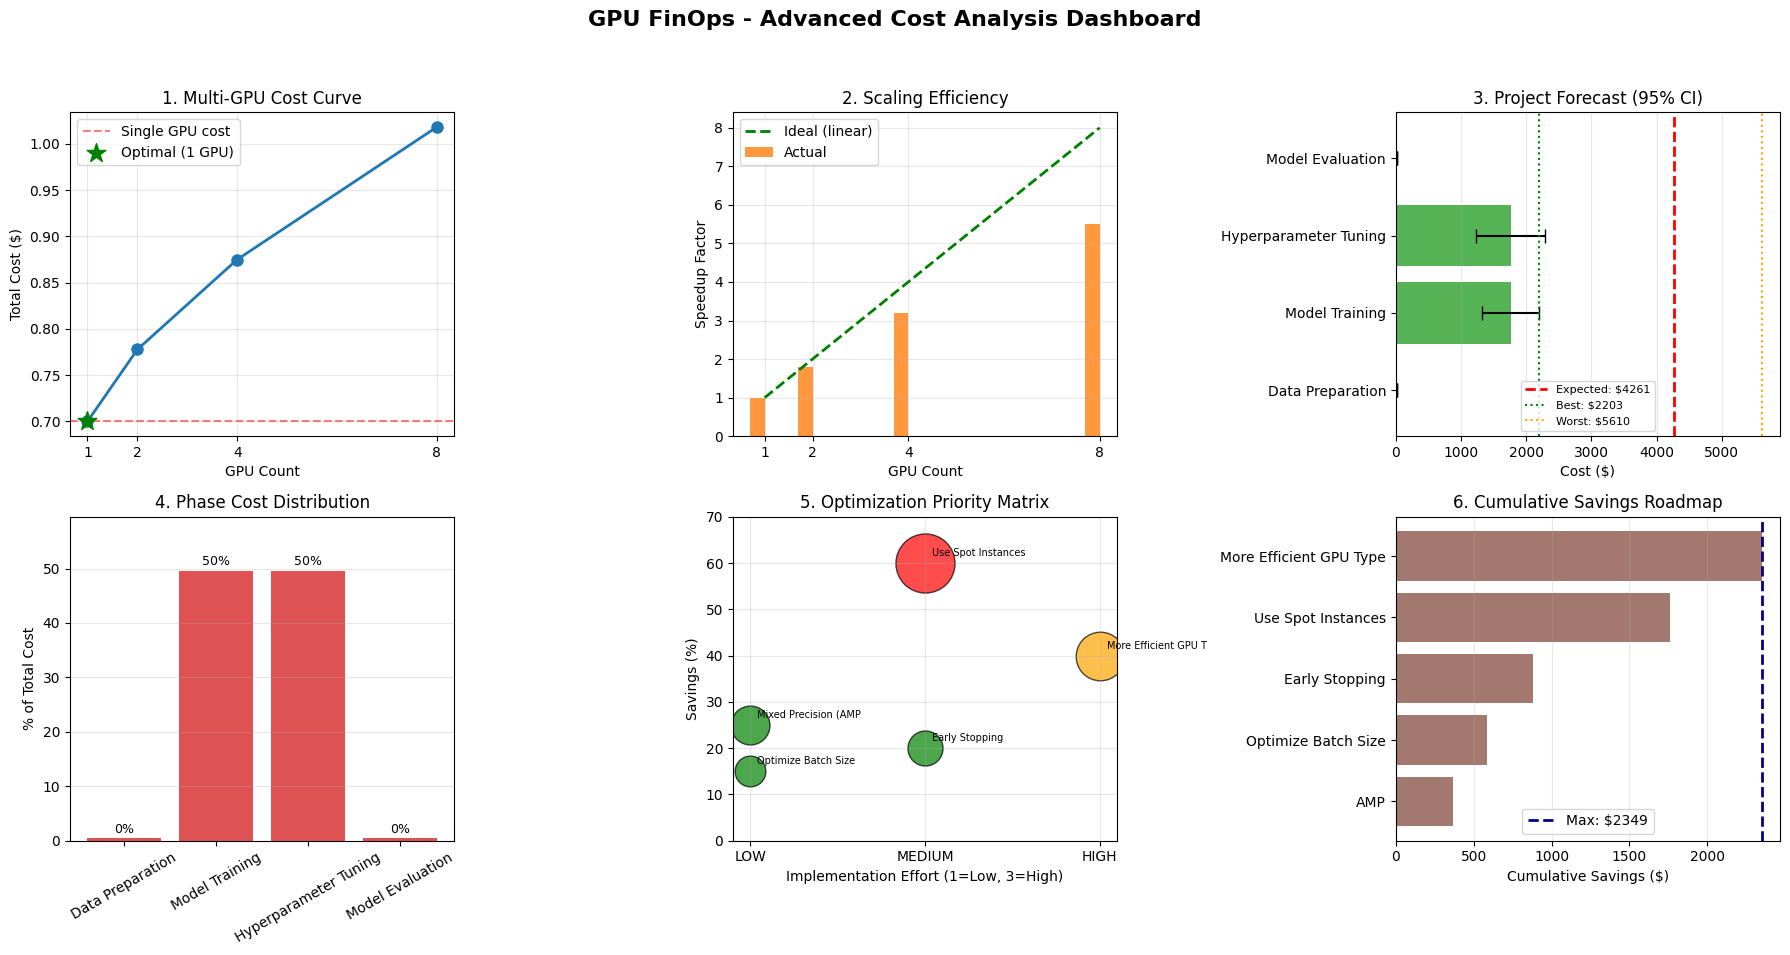


  Dashboard saved as: advanced_finops_dashboard.png


In [60]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    Create comprehensive 6-panel FinOps dashboard
    """
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("GPU FinOps - Advanced Cost Analysis Dashboard", fontsize=16, fontweight='bold')

    colors = plt.cm.tab10.colors

    # ============================================================
    # Plot 1: Multi-GPU Cost Curve
    # ============================================================
    ax1 = axes[0, 0]
    results = multi_gpu_analysis['results']
    gpu_counts = [r['gpu_count'] for r in results]
    costs = [r['total_cost'] for r in results]
    ax1.plot(gpu_counts, costs, 'o-', color=colors[0], linewidth=2, markersize=8)
    ax1.axhline(y=results[0]['total_cost'], color='red', linestyle='--', alpha=0.5, label='Single GPU cost')
    # Highlight optimal
    optimal_idx = costs.index(min(costs))
    ax1.scatter([gpu_counts[optimal_idx]], [costs[optimal_idx]], color='green', s=200, zorder=5, marker='*', label=f'Optimal ({gpu_counts[optimal_idx]} GPU)')
    ax1.set_xlabel("GPU Count")
    ax1.set_ylabel("Total Cost ($)")
    ax1.set_title("1. Multi-GPU Cost Curve")
    ax1.set_xticks(gpu_counts)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ============================================================
    # Plot 2: Scaling Efficiency
    # ============================================================
    ax2 = axes[0, 1]
    scaling = [r['scaling_factor'] for r in results]
    speedup = [r['speedup'] for r in results]
    ideal = gpu_counts  # Linear scaling
    ax2.plot(gpu_counts, ideal, 'g--', linewidth=2, label='Ideal (linear)')
    ax2.bar([x - 0.15 for x in gpu_counts], speedup, width=0.3, label='Actual', color=colors[1], alpha=0.8)
    ax2.set_xlabel("GPU Count")
    ax2.set_ylabel("Speedup Factor")
    ax2.set_title("2. Scaling Efficiency")
    ax2.set_xticks(gpu_counts)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ============================================================
    # Plot 3: Project Forecast with Confidence Bands
    # ============================================================
    ax3 = axes[0, 2]
    phases = project_forecast['phases']
    names = [p['name'] for p in phases]
    base_costs = [p['base_cost'] for p in phases]
    uncertainties = [p['uncertainty_range'] for p in phases]

    y_pos = np.arange(len(names))
    ax3.barh(y_pos, base_costs, xerr=uncertainties, capsize=5, color=colors[2], alpha=0.8)
    ax3.axvline(x=project_forecast['forecast_expected'], color='red', linestyle='--', linewidth=2,
                label=f"Expected: ${project_forecast['forecast_expected']:.0f}")
    ax3.axvline(x=project_forecast['forecast_best'], color='green', linestyle=':', linewidth=1.5,
                label=f"Best: ${project_forecast['forecast_best']:.0f}")
    ax3.axvline(x=project_forecast['forecast_worst'], color='orange', linestyle=':', linewidth=1.5,
                label=f"Worst: ${project_forecast['forecast_worst']:.0f}")
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(names)
    ax3.set_xlabel("Cost ($)")
    ax3.set_title("3. Project Forecast (95% CI)")
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis='x')

    # ============================================================
    # Plot 4: Phase-by-Phase Cost Breakdown
    # ============================================================
    ax4 = axes[1, 0]
    pct_totals = [p['pct_of_total'] for p in phases]
    bars = ax4.bar(names, pct_totals, color=colors[3], alpha=0.8)
    ax4.set_ylabel("% of Total Cost")
    ax4.set_title("4. Phase Cost Distribution")
    ax4.tick_params(axis='x', rotation=30)
    for bar, pct in zip(bars, pct_totals):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, max(pct_totals) * 1.2)

    # ============================================================
    # Plot 5: Optimization Prioritization Matrix (Savings vs Effort)
    # ============================================================
    ax5 = axes[1, 1]
    strategies = optimization_recommendations['strategies']
    effort_map = {'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}
    for i, s in enumerate(strategies):
        effort_num = effort_map.get(s['effort'], 2)
        color = 'green' if s['risk'] == 'LOW' else 'orange' if s['risk'] == 'MEDIUM' else 'red'
        size = s['savings_dollar'] * 2 + 50
        ax5.scatter(effort_num, s['savings_pct'] * 100, s=size, c=color, alpha=0.7, edgecolors='black')
        ax5.annotate(s['name'].replace('Switch to ', '').replace('Implement ', '')[:20],
                     (effort_num, s['savings_pct'] * 100),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
    ax5.set_xlabel("Implementation Effort (1=Low, 3=High)")
    ax5.set_ylabel("Savings (%)")
    ax5.set_title("5. Optimization Priority Matrix")
    ax5.set_xticks([1, 2, 3])
    ax5.set_xticklabels(['LOW', 'MEDIUM', 'HIGH'])
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim(0, 70)

    # ============================================================
    # Plot 6: Cumulative Savings Roadmap
    # ============================================================
    ax6 = axes[1, 2]
    strategy_names = [s['name'].replace('Switch to ', '').replace('Implement ', '').replace('Mixed Precision (AMP)', 'AMP')
                     for s in strategies]
    cumulative = [s['cumulative_savings'] for s in strategies]
    colors_bar = [colors[5] if c > 0 else colors[6] for c in cumulative]
    bars6 = ax6.barh(strategy_names, cumulative, color=colors_bar, alpha=0.8)
    ax6.axvline(x=optimization_recommendations['total_savings_dollar'], color='darkblue',
                linestyle='--', linewidth=2, label=f"Max: ${optimization_recommendations['total_savings_dollar']:.0f}")
    ax6.set_xlabel("Cumulative Savings ($)")
    ax6.set_title("6. Cumulative Savings Roadmap")
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='x')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fig


# Build data from previous exercises (placeholder if not yet implemented)
try:
    mg = analyze_multi_gpu_cost(2.0, 'T4', [1, 2, 4, 8])
except NameError:
    mg = {
        'results': [
            {'gpu_count': 1, 'scaling_factor': 1.0, 'total_cost': 0.70, 'speedup': 1.0},
            {'gpu_count': 2, 'scaling_factor': 1.8, 'total_cost': 0.78, 'speedup': 1.8},
            {'gpu_count': 4, 'scaling_factor': 3.2, 'total_cost': 0.88, 'speedup': 3.2},
            {'gpu_count': 8, 'scaling_factor': 5.5, 'total_cost': 1.02, 'speedup': 5.5},
        ]
    }

try:
    pf = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
except NameError:
    pf = forecast_project_cost([
        {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
        {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
        {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
        {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
    ], contingency_pct=20, confidence_level=0.95)

try:
    opt = analyze_optimization_opportunities(current_training_config, example_strategies)
except NameError:
    opt = analyze_optimization_opportunities(
        {"gpu_type": "A100", "gpu_count": 4, "duration_hours": 100, "precision": "FP32", "instance_type": "on-demand"},
        [
            {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
            {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
            {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
            {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
            {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
        ]
    )

fig = create_advanced_finops_dashboard(mg, pf, opt)
print(f"\n  Dashboard saved as: advanced_finops_dashboard.png")

In [56]:
display_student_header()

In [62]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # <-- budget ở ĐÂY
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("\n  CHALLENGE SCENARIO:")
print(f"    Project: {challenge_scenario['project']}")
print(f"    Baseline: {challenge_scenario['requirements']['gpu_count']}x "
      f"{challenge_scenario['requirements']['gpu_type']} for "
      f"{challenge_scenario['requirements']['training_duration']}h")
print(f"    Budget: ${challenge_scenario['requirements']['budget']}")  # FIX: requirements, not constraints

# STEP 1: Baseline cost
req = challenge_scenario['requirements']
baseline_cost = req['training_duration'] * GPU_PRICING[req['gpu_type']] * req['gpu_count']
budget = req['budget']  # shorthand

print(f"\n  {'='*55}")
print(f"  STEP 1: BASELINE = ${baseline_cost:.2f} "
      f"({'OVER' if baseline_cost > budget else 'UNDER'} budget)")

# STEP 2: Multi-GPU analysis
gpu_options = [1, 2, 4, 8, 16]
mg = analyze_multi_gpu_cost(req['training_duration'], req['gpu_type'], gpu_options)
under_budget = [r for r in mg['results'] if r['total_cost'] <= budget]
optimal = max(under_budget, key=lambda x: x['speedup']) if under_budget else min(mg['results'], key=lambda x: x['total_cost'])

print(f"\n  {'='*55}")
print(f"  STEP 2: OPTIMAL GPU CONFIG = {optimal['gpu_count']} GPU(s)")
print(f"    Time: {optimal['time_hours']:.1f}h | Cost: ${optimal['total_cost']:.2f} | Speedup: {optimal['speedup']:.1f}x")

# STEP 3: Strategy selection
all_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW"},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH"},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW"},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW"},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM"},
    {"name": "Gradient Checkpointing", "savings_pct": 0.18, "implementation_effort": "LOW", "risk_level": "LOW"},
]

risk_order = {'LOW': 0, 'MEDIUM': 1}
risk_filter = challenge_scenario['constraints']['max_preemption_risk']
allowed = [s for s in all_strategies if risk_order.get(s['risk_level'], 2) <= risk_order.get(risk_filter, 1)]
effort_score = {'LOW': 1, 'MEDIUM': 3, 'HIGH': 7}
scored = sorted(allowed, key=lambda x: x['savings_pct'] / effort_score[x['implementation_effort']], reverse=True)

selected, cumulative_savings = [], 0.0
optimal_base = optimal['total_cost']
for s in scored:
    projected = optimal_base - (cumulative_savings + optimal_base * s['savings_pct'])
    if projected >= 0:
        selected.append(s)
        cumulative_savings += optimal_base * s['savings_pct']

print(f"\n  {'='*55}")
print(f"  STEP 3: SELECTED OPTIMIZATIONS ({len(selected)} strategies)")
for s in selected:
    print(f"    + {s['name']} ({s['savings_pct']*100:.0f}% off, {s['implementation_effort']} effort)")

# STEP 4: Forecast with CI
from math import sqrt
z, unc = 1.96, 0.15
final_expected = optimal_base - cumulative_savings
ci_half = z * (final_expected * unc)
contingency = final_expected * 0.10

print(f"\n  {'='*55}")
print(f"  STEP 4: FORECAST (95% CI)")
print(f"    Expected:  ${final_expected:.2f}")
print(f"    Best:     ${final_expected - ci_half:.2f}")
print(f"    Worst:    ${final_expected + ci_half + contingency:.2f}")

# STEP 5: Constraint verification
print(f"\n  {'='*55}")
print(f"  STEP 5: CONSTRAINT VERIFICATION")
budget_ok = final_expected <= budget
time_days = optimal['time_hours'] / 24
deadline_ok = time_days <= 14
print(f"    Budget (${budget}):   {'PASS' if budget_ok else 'FAIL'} -> ${final_expected:.2f}")
print(f"    Deadline (14d):       {'PASS' if deadline_ok else 'FAIL'} -> {time_days:.1f}d")

# STEP 6: Summary
print(f"\n  {'='*55}")
print(f"  FINAL STRATEGY SUMMARY")
print(f"  {'='*55}")
total_reduction = (baseline_cost - final_expected) / baseline_cost * 100
print(f"    Baseline:  ${baseline_cost:.2f} -> Optimized: ${final_expected:.2f}")
print(f"    Savings:   ${baseline_cost - final_expected:.2f} ({total_reduction:.1f}%)")
print(f"    GPU:       {optimal['gpu_count']}x {req['gpu_type']} ({optimal['speedup']:.1f}x speedup)")
print(f"    Checks:    {'ALL PASS' if budget_ok and deadline_ok else 'REVIEW NEEDED'}")
print(f"  {'='*55}")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy

  CHALLENGE SCENARIO:
    Project: Large Language Model Fine-tuning
    Baseline: 8x A100 for 200h
    Budget: $5000

  STEP 1: BASELINE = $5872.00 (OVER budget)

  STEP 2: OPTIMAL GPU CONFIG = 16 GPU(s)
    Time: 22.2h | Cost: $1304.89 | Speedup: 9.0x

  STEP 3: SELECTED OPTIMIZATIONS (4 strategies)
    + Switch to Mixed Precision (AMP) (25% off, LOW effort)
    + Gradient Checkpointing (18% off, LOW effort)
    + Optimize Batch Size (15% off, LOW effort)
    + Implement Early Stopping (20% off, MEDIUM effort)

  STEP 4: FORECAST (95% CI)
    Expected:  $287.08
    Best:     $202.68
    Worst:    $400.18

  STEP 5: CONSTRAINT VERIFICATION
    Budget ($5000):   PASS -> $287.08
    Deadline (14d):       PASS -> 0.9d

  FINAL STRATEGY SUMMARY
    Baseline:  $5872.00 -> Optimized: $287.08
    Savings:   $5584.92 (95.1%)
    GPU:       16x A100 (9.0x speedup)
    Checks:    ALL PASS


In [57]:
display_student_header()

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway